In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import Image as IPImage
from PIL import Image

In [1]:
def mhd_2d_frames(J, K, N, P):
    """
    Generates snapshots of solution of 2D MHD equations.

    Parameters
    ----------
    J : int
        Number of grid cells in x-direction per processor
    K : int
        Total number of grid cells in y-direction
    N : int
        Total number of outputs generated by CentPack
    P : int
        Number of processors used in the simulation
    """

    os.chdir('/Users/evandaniels/Research/CentPackL/simulation_MHD2d_SD2')

    y = np.loadtxt('mesh_files/y')

    x = np.array([])
    for p in range(P):
        x_file = f'mesh_files/x_p{p:03d}'
        xp = np.loadtxt(x_file)
        x = np.concatenate([x, xp])

    sub_sample = 16

    xx = x[::sub_sample]
    yy = y[::sub_sample]

    for n in range(N):

        rho = []
        u1  = []
        u3  = []
        b1  = []
        b3  = []
        press = []

        for p in range(P):
            rho.append(np.loadtxt(f'rho_files/rho_p{p:03d}_{n:03d}'))
            u1.append( np.loadtxt(f'u1_files/u1_p{p:03d}_{n:03d}'))
            u3.append( np.loadtxt(f'u3_files/u3_p{p:03d}_{n:03d}'))
            b1.append( np.loadtxt(f'b1_files/b1_p{p:03d}_{n:03d}'))
            b3.append( np.loadtxt(f'b3_files/b3_p{p:03d}_{n:03d}'))
            press.append(np.loadtxt(f'p_files/p_p{p:03d}_{n:03d}'))

        rho   = np.vstack(rho)
        u1    = np.vstack(u1)
        u3    = np.vstack(u3)
        b1    = np.vstack(b1)
        b3    = np.vstack(b3)
        press = np.vstack(press)

        ux = u1[::sub_sample, ::sub_sample]
        uy = u3[::sub_sample, ::sub_sample]
        bx = b1[::sub_sample, ::sub_sample]
        by = b3[::sub_sample, ::sub_sample]

        if n > 0:
            fig, ax = plt.subplots()
            cf = ax.contourf(x, y, rho.T, levels=np.linspace(0, 10, 20), vmin=0, vmax=10)
            fig.colorbar(cf, ax=ax, label='Density')
            # ax.contourf(x, y, rho.T, 20)
            ax.set_aspect('equal')
            fig.savefig(f'rho_frames/rho_{n:03d}.png', dpi=100)
            plt.close(fig)

        fig, ax = plt.subplots()
        # ax.quiver(xx, yy, ux.T, uy.T, scale=1/1.5)
        ax.quiver(xx, yy, bx.T, by.T)
        ax.set_xlim(0, 2*np.pi); ax.set_ylim(0, 2*np.pi)
        ax.set_aspect('equal')
        fig.savefig(f'u_frames/u_{n:03d}.png', dpi=100)
        plt.close(fig)

        fig, ax = plt.subplots()
        # ax.quiver(xx, yy, bx.T, by.T, scale=1/1.5)
        ax.quiver(xx, yy, bx.T, by.T)
        ax.set_xlim(0, 2*np.pi); ax.set_ylim(0, 2*np.pi)
        ax.set_aspect('equal')
        fig.savefig(f'b_frames/b_{n:03d}.png', dpi=100)
        plt.close(fig)

        fig, ax = plt.subplots()
        cf = ax.contourf(x, y, press.T, levels=np.linspace(0, 10, 20), vmin=0, vmax=9)
        fig.colorbar(cf, ax=ax, label='Pressure')
        # ax.contourf(x, y, press.T, 20)
        ax.set_xlim(0, 2*np.pi); ax.set_ylim(0, 2*np.pi)
        ax.set_aspect('equal')
        fig.savefig(f'p_frames/p_{n:03d}.png', dpi=100)
        plt.close(fig)

        print(f'Frame {n+1}/{N} done')

In [3]:
mhd_2d_frames(36, 144, 60, 8) # J, K, N, P

Frame 1/60 done
Frame 2/60 done
Frame 3/60 done
Frame 4/60 done
Frame 5/60 done
Frame 6/60 done
Frame 7/60 done
Frame 8/60 done
Frame 9/60 done
Frame 10/60 done
Frame 11/60 done
Frame 12/60 done
Frame 13/60 done
Frame 14/60 done
Frame 15/60 done
Frame 16/60 done
Frame 17/60 done
Frame 18/60 done
Frame 19/60 done
Frame 20/60 done
Frame 21/60 done
Frame 22/60 done
Frame 23/60 done
Frame 24/60 done
Frame 25/60 done
Frame 26/60 done
Frame 27/60 done
Frame 28/60 done
Frame 29/60 done
Frame 30/60 done
Frame 31/60 done
Frame 32/60 done
Frame 33/60 done
Frame 34/60 done
Frame 35/60 done
Frame 36/60 done
Frame 37/60 done
Frame 38/60 done
Frame 39/60 done
Frame 40/60 done
Frame 41/60 done
Frame 42/60 done
Frame 43/60 done
Frame 44/60 done
Frame 45/60 done
Frame 46/60 done
Frame 47/60 done
Frame 48/60 done
Frame 49/60 done
Frame 50/60 done
Frame 51/60 done
Frame 52/60 done
Frame 53/60 done
Frame 54/60 done
Frame 55/60 done
Frame 56/60 done
Frame 57/60 done
Frame 58/60 done
Frame 59/60 done
Frame 

In [4]:
def frames_to_gif(frame_dir, output_name, duration=100):
    frames = sorted(glob.glob(f'{frame_dir}/*.png'))
    images = [Image.open(f) for f in frames]
    images[0].save(
        output_name,
        save_all=True,
        append_images=images[1:],
        loop=0,
        duration=duration  # milliseconds per frame
    )

frames_to_gif('rho_frames', 'rho.gif')
frames_to_gif('u_frames',  'u.gif')
frames_to_gif('p_frames',   'p.gif')
frames_to_gif('b_frames',   'b.gif')

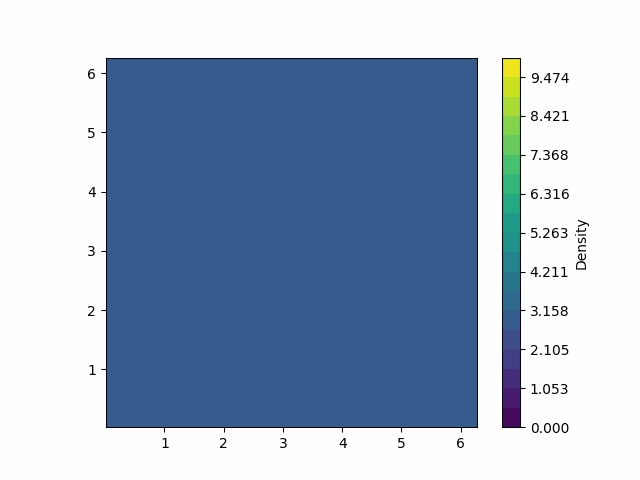

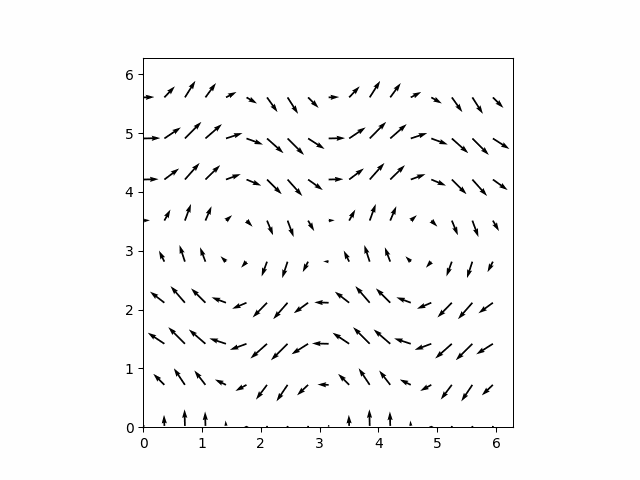

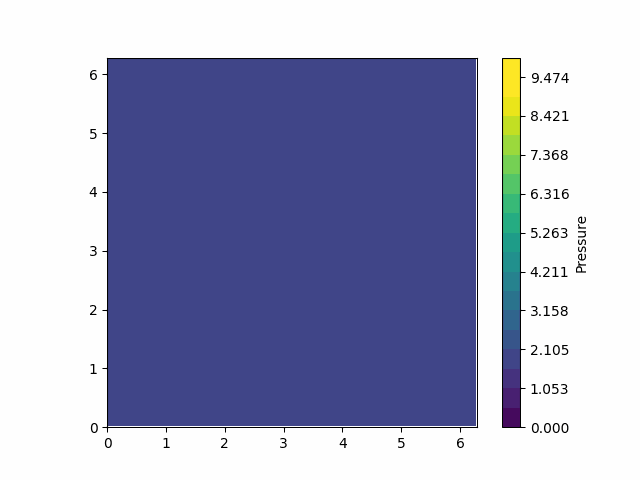

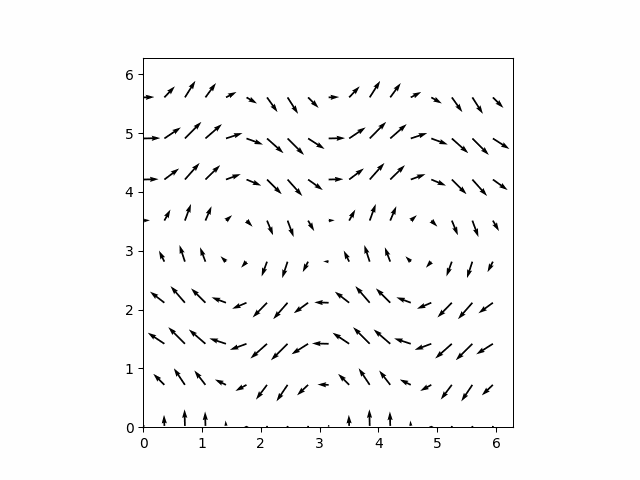

In [5]:
display(IPImage('rho.gif'))
display(IPImage('u.gif'))
display(IPImage('p.gif'))
display(IPImage('b.gif'))